# 04 — Phase 1: Rank Sweep  ⏱️ OFFLINE — pre-run before the demo

This is the heavy, pre-computed stage. For every compressible 3×3 conv it
sweeps a 2D grid of `(r_in, r_out)` ranks, and for each combination measures:

- **noise %** — the std-based activation-error metric (identical to the
  CNN/ViT pipeline), comparing the original conv's output to the Tucker
  block's output on a stratified sample.
- **mAP@0.5** — detection quality on a subsampled validation set (the
  object-detection analog of the CNN pipeline's top-1 accuracy).

It then fits a symmetrized degree-4 (biquadratic) polynomial of **mAP vs
noise** per layer. Everything is checkpointed per layer to JSON so this can
run offline on the DGX and the results carried to the demo machine — the
live demo only runs Phase 2 on these stored results.

**Methodology note:** this faithfully mirrors the validated CNN pipeline
(full deep-copy per combo, full Tucker + spatial folding, std-based noise,
symmetrized even-polynomial fit). The one task substitution is mAP@0.5 in
place of top-1 accuracy on the polynomial's y-axis.

In [2]:
import sys, os, json
sys.path.append(os.path.abspath("../src"))
import torch
from model import YOLOv3

with open("../checkpoints/run_config.json") as f:
    cfg = json.load(f)
NUM_CLASSES = len(cfg["class_names"])

model = YOLOv3(num_classes=NUM_CLASSES)
state = torch.load("../checkpoints/yolov3_best.pt", map_location="cpu")
model.load_state_dict(state["model_state"])
print("checkpoint loads cleanly — no retraining needed")

/tmp/ipykernel_1293/2034779388.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("../checkpoints/yolov3_best.pt", map_location="cpu")


checkpoint loads cleanly — no retraining needed


In [4]:
import sys, os, json
sys.path.append(os.path.abspath("../src"))
import torch
from torch.utils.data import DataLoader

from model import YOLOv3
from dataset import CocoSubsetDataset, yolo_collate_fn
from tucker_pipeline import get_compressible_layers, fit_biquadratic_polynomial
from tucker_phase1 import evaluate_map, run_phase1

with open("../checkpoints/run_config.json") as f:
    cfg = json.load(f)
CLASS_NAMES, IMG_SIZE, DATA_ROOT, BATCH_SIZE = cfg["class_names"], cfg["img_size"], cfg["data_root"], cfg["batch_size"]
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Load the trained baseline model

In [5]:
model = YOLOv3(num_classes=NUM_CLASSES)
state = torch.load("../checkpoints/yolov3_best.pt", map_location=DEVICE)
model.load_state_dict(state["model_state"])
model.to(DEVICE).eval()
print("loaded trained baseline")

/tmp/ipykernel_1293/4262044427.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("../checkpoints/yolov3_best.pt", map_location=DEVICE)


loaded trained baseline


## Build the validation loader + stratified sample

The **val loader** feeds the (subsampled) mAP evaluation. The **stratified
sample** feeds the noise metric — a handful of images per class is plenty,
since each image contributes hundreds of thousands of activation values to
the std-based noise estimate (same rationale as the CNN pipeline's 1-per-class).

In [6]:
val_ds = CocoSubsetDataset(DATA_ROOT, "val2017", CLASS_NAMES, img_size=IMG_SIZE,
                            images_per_class=30, augment=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=yolo_collate_fn, num_workers=0)

# stratified sample for noise: reuse a few val images per class
strat_ds = CocoSubsetDataset(DATA_ROOT, "val2017", CLASS_NAMES, img_size=IMG_SIZE,
                              images_per_class=2, augment=False)
X_sample = torch.stack([strat_ds[i][0] for i in range(len(strat_ds))], dim=0)
print("stratified sample:", tuple(X_sample.shape))

loading annotations into memory...
Done (t=0.46s)
creating index...
index created!
loading annotations into memory...
Done (t=0.42s)
creating index...
index created!
stratified sample: (10, 3, 416, 416)


## Baseline mAP (uncompressed reference)

Measured once up front — Phase 2 uses this as the reference the accuracy budget is subtracted from.

In [7]:
baseline_map = evaluate_map(model, val_loader, NUM_CLASSES, DEVICE, IMG_SIZE, max_batches=None)
print(f"baseline mAP@0.5: {baseline_map:.4f}")

os.makedirs("../checkpoints/phase1", exist_ok=True)
with open("../checkpoints/phase1/baseline.json", "w") as f:
    json.dump({"baseline_map": baseline_map}, f)

baseline mAP@0.5: 0.0402


## Enumerate compressible layers (37 for YOLOv3: 3×3 convs, skip stem + prediction heads)

In [8]:
compressible = get_compressible_layers(model, skip_first=True)
print(f"{len(compressible)} compressible layers")
total = 0
for l in compressible:
    step = max(1, int(round(0.20 * min(l["C_in"], l["C_out"]))))
    import math
    n_in = len(list(range(step, l["C_in"]+1, step))) + (1 if l["C_in"] % step else 0)
    n_out = len(list(range(step, l["C_out"]+1, step))) + (1 if l["C_out"] % step else 0)
    total += n_in * n_out
print(f"~{total} total (r_in, r_out) combinations across all layers")

37 compressible layers
~2202 total (r_in, r_out) combinations across all layers


## Run Phase 1

⚠️ **This is the long-running cell.** Faithful to the CNN pipeline, it
deep-copies the full model per combination and evaluates mAP + noise. On the
DGX GPU this is feasible offline but not fast — leave it running. It
checkpoints after every layer to `../checkpoints/phase1/phase1_layerNNN.json`
and **resumes automatically** if interrupted (skips layers already done).

Tune `MAP_MAX_BATCHES` down to speed up the sweep (fewer val batches per mAP
estimate) or up for more accurate curves. Since Phase 1 is pre-run offline,
you can afford a reasonably large value here for trustworthy polynomials.

In [9]:
MAP_MAX_BATCHES = 20   # val batches per mAP estimate (subsampling for tractability)
NOISE_BATCH_SIZE = 8

layer_results = run_phase1(
    model, compressible, X_sample, val_loader, NUM_CLASSES, DEVICE, IMG_SIZE,
    ckpt_dir="../checkpoints/phase1",
    map_max_batches=MAP_MAX_BATCHES, noise_batch_size=NOISE_BATCH_SIZE)
print(f"\nPhase 1 done: {len(layer_results)} layers")


[Phase1] layer 1/37: backbone.stage1.0.0

  Layer: backbone.stage1.0.0  C_in=32 C_out=64 step=6 combos=66
    [  1/66] r_in=   6 r_out=   6 | noise= 77.49% mAP=0.0296 CR=20.48x (3.6s)
    [  2/66] r_in=   6 r_out=  12 | noise= 69.08% mAP=0.0295 CR=11.46x (4.0s)
    [  3/66] r_in=   6 r_out=  18 | noise= 64.54% mAP=0.0334 CR=7.96x (4.2s)
    [  4/66] r_in=   6 r_out=  24 | noise= 60.82% mAP=0.0262 CR=6.10x (3.8s)
    [  5/66] r_in=   6 r_out=  30 | noise= 61.59% mAP=0.0265 CR=4.94x (3.6s)
    [  6/66] r_in=   6 r_out=  36 | noise= 60.01% mAP=0.0268 CR=4.15x (3.7s)
    [  7/66] r_in=   6 r_out=  42 | noise= 59.12% mAP=0.0262 CR=3.58x (3.9s)
    [  8/66] r_in=   6 r_out=  48 | noise= 59.26% mAP=0.0261 CR=3.15x (3.9s)
    [  9/66] r_in=   6 r_out=  54 | noise= 59.20% mAP=0.0268 CR=2.81x (4.0s)
    [ 10/66] r_in=   6 r_out=  60 | noise= 59.20% mAP=0.0262 CR=2.53x (3.9s)
    [ 11/66] r_in=   6 r_out=  64 | noise= 59.20% mAP=0.0268 CR=2.38x (3.9s)
    [ 12/66] r_in=  12 r_out=   6 | noise= 7

## Quick look: noise-vs-mAP curve for one layer

Sanity-check that the fitted biquadratic tracks the swept points.

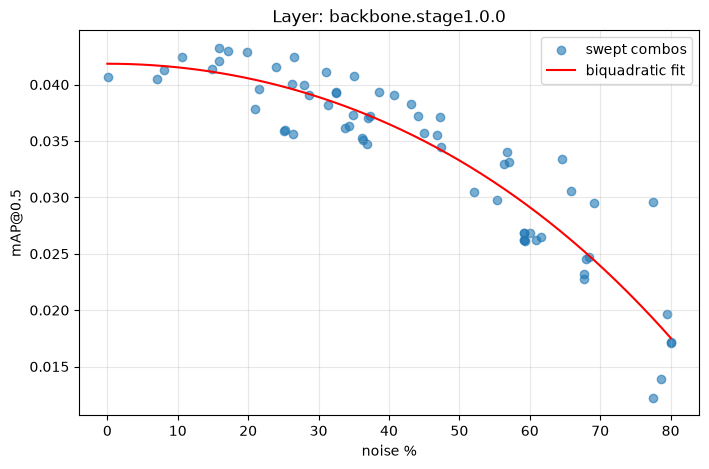

In [10]:
import numpy as np
import matplotlib.pyplot as plt

li = next(l for l in layer_results if l["poly_coeffs"] is not None)
sweep = [r for r in li["sweep_results"] if not np.isnan(r["noise_percent"])]
noise = [r["noise_percent"] for r in sweep]
mAP = [r["mAP"] for r in sweep]

xs = np.linspace(0, max(noise), 200)
poly = np.poly1d(li["poly_coeffs"])
plt.figure(figsize=(8, 5))
plt.scatter(noise, mAP, alpha=0.6, label="swept combos")
plt.plot(xs, poly(xs), "r-", label="quartic fit")
plt.xlabel("noise %"); plt.ylabel("mAP@0.5"); plt.title(f"Layer: {li['name']}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Output

`../checkpoints/phase1/phase1_layerNNN.json` (one per layer) + `baseline.json`.
These are the only things Phase 2 needs — carry this folder to the demo machine.